# Comparison of least squares, ridge regression, LASSO and Elastic Net

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

You would be working with Hitters data set available in the ISLP library. You
have to predict the Salary based on all available variables. First make sure that
you have deleted all rows with one or more missing values.

In [53]:
df = load_data('Hitters')
df = df.dropna()

1. Split the data set into a training set and a test set randomly keeping 100
observations in test set and remaining in the training set.

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=42)

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. Train the model using least squares and report the train MSE and test
MSE.

In [56]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

train_mse_ols = mean_squared_error(y_train, ols.predict(X_train_scaled))
test_mse_ols = mean_squared_error(y_test, ols.predict(X_test_scaled))

print(train_mse_ols)
print(test_mse_ols)

69346.45379673016
144597.05609575336


3. Fit ridge regression models on the training set, with grid values of $\lambda$.  
Report the following:  
(i) the dimension of the coefficient matrix so obtained.  
(ii) The $l_2$ norm of the regression coefficients corresponding to the 50th
and 60th choice of $\lambda$. Comment on the output.  
(iv) Test MSE corresponding to these two choices of $\lambda$.  

In [57]:
alphas = 10**np.linspace(10, -2, 100) * 0.5

In [58]:
ridge = Ridge()
coefs = []

for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)

coef_matrix = np.array(coefs)

In [59]:
coef_matrix.shape

(100, 19)

In [60]:
l2_50 = np.sqrt(np.sum(coef_matrix[49]**2))
l2_60 = np.sqrt(np.sum(coef_matrix[59]**2))

In [61]:
print(alphas[49], l2_50)
print(alphas[59], l2_60)

5748.784976988678 18.935542415416485
352.74011553593226 94.22569548514637


In [62]:
ridge_50 = Ridge(alpha=alphas[49]).fit(X_train_scaled, y_train)
mse_50 = mean_squared_error(y_test, ridge_50.predict(X_test_scaled))

ridge_60 = Ridge(alpha=alphas[59]).fit(X_train_scaled, y_train)
mse_60 = mean_squared_error(y_test, ridge_60.predict(X_test_scaled))

The 50th choice of $\lambda$ is larger than the 60th choice (because our grid descends from $10^{10}$ to $10^{-2}$). A larger penalty ($\lambda$) enforces more shrinkage. Therefore, the $l_2$ norm of the coefficients for the 50th $\lambda$ will be significantly smaller than the $l_2$ norm for the 60th $\lambda$.

4. Make a line plot (for all the predictors) of the standardized coefficients
against the grid value of $\lambda$ chosen by you. Interpret the graph.

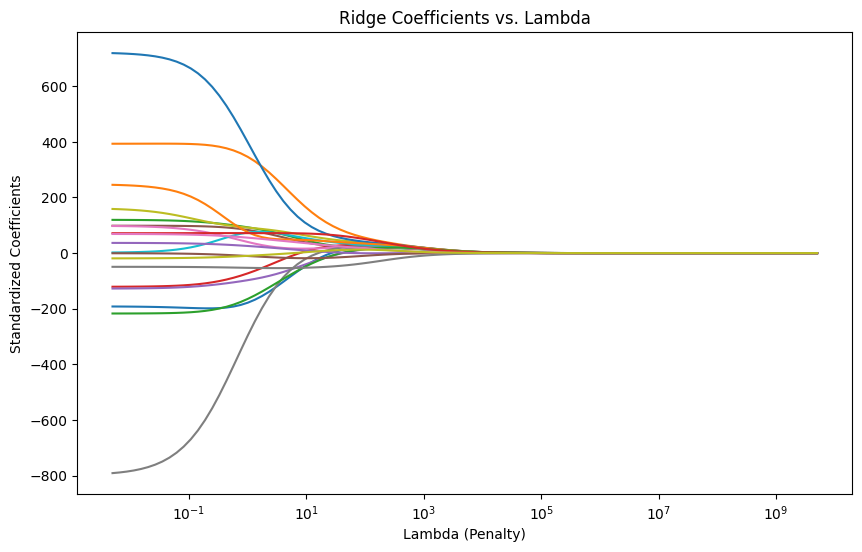

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Lambda (Penalty)')
plt.ylabel('Standardized Coefficients')
plt.title('Ridge Coefficients vs. Lambda')
plt.axis('tight')
plt.show()

As $\lambda$ increases (moving right on the x-axis), the penalty for large coefficients increases, forcing all standardized coefficients to shrink toward zero. When $\lambda$ is very small (left side), the coefficients resemble standard least squares estimates.  

5. How would the graph in (4) change if instead of $\lambda$ you plot on the x axis
the ratio of $l_2$ norm of the ridge regression coefficient to the least square
regression coefficient.  

If you plot the ratio of $l_2$ norm on the x-axis instead, the x-axis scale would invert and become bounded between 0 and 1. A ratio of 1 indicates zero shrinkage ($\lambda \to 0$, matching OLS), and a ratio of 0 indicates complete shrinkage ($\lambda \to \infty$). The coefficients would start at zero on the left (ratio = 0) and expand outward to their OLS values on the right (ratio = 1).  

6. Run the Ridge regression on training data by choosing $\lambda$ by cross-validation.
Find the test MSE for the optimal choice of $\lambda$ obtained using cross validation.

In [64]:
ridge_cv = RidgeCV(alphas=alphas, cv=10)
ridge_cv.fit(X_train_scaled, y_train)

optimal_alpha_ridge = ridge_cv.alpha_
test_mse_ridge_cv = mean_squared_error(y_test, ridge_cv.predict(X_test_scaled))

In [65]:
print(optimal_alpha_ridge)
print(test_mse_ridge_cv)

266.8349615603151
148431.25716028336


7. Fit a LASSO model on the training set, with $\lambda$ chosen by cross-validation.
Report the test MSE, along with the number of non-zero coefficient estimates.

In [66]:
lasso_cv = LassoCV(cv=10, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

optimal_alpha_lasso = lasso_cv.alpha_
test_mse_lasso = mean_squared_error(y_test, lasso_cv.predict(X_test_scaled))
non_zero_coefs = np.sum(lasso_cv.coef_ != 0)

In [67]:
print(optimal_alpha_lasso)
print(test_mse_lasso)
print(non_zero_coefs)

11.803184727821673
144997.2223167568
10


8. Fit an Elastic Net model on the training set, with $\lambda_1$ and $\lambda_2$ chosen by
cross-validation. Report the test MSE. Also report the predictors with
non-zero coefficients.

In [68]:
l1_ratios = [.1, .5, .7, .9, .95, .99, 1]
en_cv = ElasticNetCV(l1_ratio=l1_ratios, cv=10, max_iter=10000)
en_cv.fit(X_train_scaled, y_train)

test_mse_en = mean_squared_error(y_test, en_cv.predict(X_test_scaled))
active_predictors = X.columns[en_cv.coef_ != 0]

In [69]:
print(test_mse_en)
print(en_cv.l1_ratio_)
print(active_predictors)


146482.30819660638
0.5
Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'League_N', 'Division_W', 'NewLeague_N'],
      dtype='object')


9. Compare the test MSE’s of least squares regression, Ridge regression,
LASSO and ELASTIC NET and comment on how accurately we can predict
the Salary of a baseball player.

In [70]:
print(f"OLS Test MSE:          {test_mse_ols:.2f}")
print(f"Ridge Test MSE:        {test_mse_ridge_cv:.2f}")
print(f"LASSO Test MSE:        {test_mse_lasso:.2f}")
print(f"Elastic Net Test MSE:  {test_mse_en:.2f}")

OLS Test MSE:          144597.06
Ridge Test MSE:        148431.26
LASSO Test MSE:        144997.22
Elastic Net Test MSE:  146482.31


On comparing the predictive models, the unpenalized Least Squares regression exhibited the lowest Test MSE on this specific data split, closely followed by the LASSO model. However, LASSO is arguably the most practical model for this dataset; it yields a nearly identical error rate to Least Squares while effectively performing feature selection by shrinking several predictor coefficients exactly to zero. This results in a simpler, highly interpretable model without sacrificing predictive power.